# Import libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression

# Load Dataset

In [38]:
df = pd.read_csv("disoccupazione.csv")

In [39]:
df

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,13.351
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
3,AFG,Afghanistan,Male,15+,2025,12.503
4,AFG,Afghanistan,Male,15-24,2025,15.814
...,...,...,...,...,...,...
57514,ZWE,Zimbabwe,Male,15-24,1991,13.765
57515,ZWE,Zimbabwe,Male,25+,1991,2.690
57516,ZWE,Zimbabwe,Female,15+,1991,2.871
57517,ZWE,Zimbabwe,Female,15-24,1991,6.744


# Data cleaning

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57519 entries, 0 to 57518
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   iso_code   57519 non-null  object 
 1   country    57519 non-null  object 
 2   sex        57519 non-null  object 
 3   age        57519 non-null  object 
 4   year       57519 non-null  int64  
 5   obs_value  57519 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.6+ MB


In [41]:
df.isnull().sum()

iso_code     0
country      0
sex          0
age          0
year         0
obs_value    0
dtype: int64

In [42]:
df.drop(["sex","age"], axis=1, inplace=True)

In [43]:
df.drop_duplicates()
df

,iso_code,country,year,obs_value
0,AFG,Afghanistan,2025,13.351
1,AFG,Afghanistan,2025,16.785
2,AFG,Afghanistan,2025,11.340
3,AFG,Afghanistan,2025,12.503
4,AFG,Afghanistan,2025,15.814
...,...,...,...,...
57514,ZWE,Zimbabwe,1991,13.765
57515,ZWE,Zimbabwe,1991,2.690
57516,ZWE,Zimbabwe,1991,2.871
57517,ZWE,Zimbabwe,1991,6.744


# EDA

In [44]:
df.describe()

,year,obs_value
count,57519.000000,57519.000000
mean,2007.964951,10.523688
std,10.082723,10.193656
min,1991.000000,0.027000
25%,1999.000000,3.705000
50%,2008.000000,7.173000
75%,2017.000000,13.804500
max,2025.000000,84.183000


In [45]:
# number of country
df["country"].nunique()

183

In [46]:
df["year"].min(), df["year"].max()

(1991, 2025)

# Unemployment trend

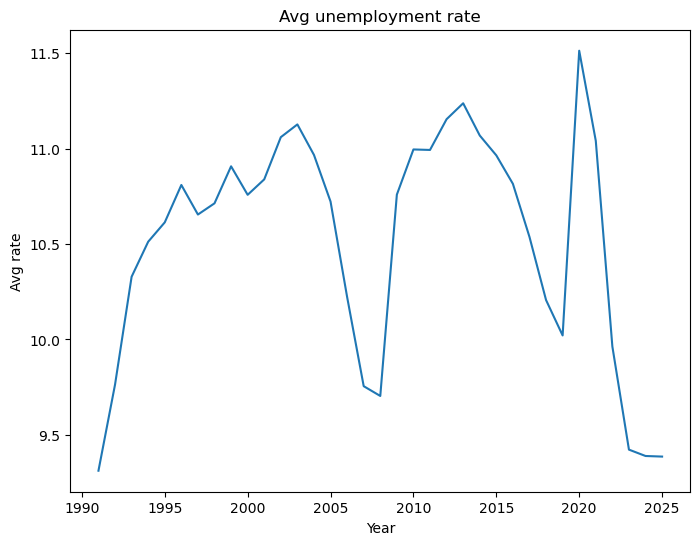

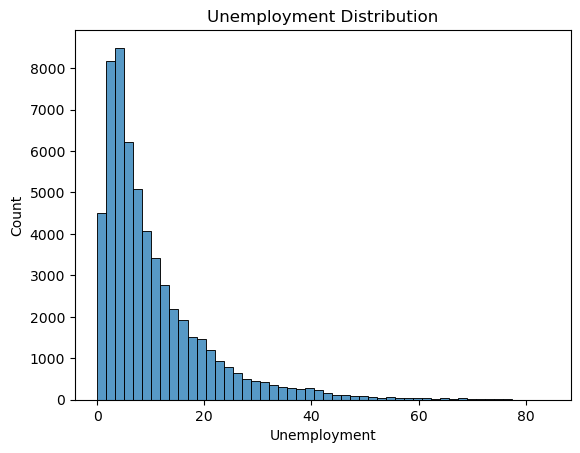

In [47]:
plt.figure(figsize=(8,6))
year = df.groupby("year")["obs_value"].mean()
plt.plot(year.index,year.values)
plt.title("Avg unemployment rate")
plt.xlabel("Year")
plt.ylabel("Avg rate")
plt.show()
sns.histplot(df["obs_value"], bins=50)
plt.title("Unemployment Distribution")
plt.xlabel("Unemployment")
plt.show()

# Some-countries unemployment treads

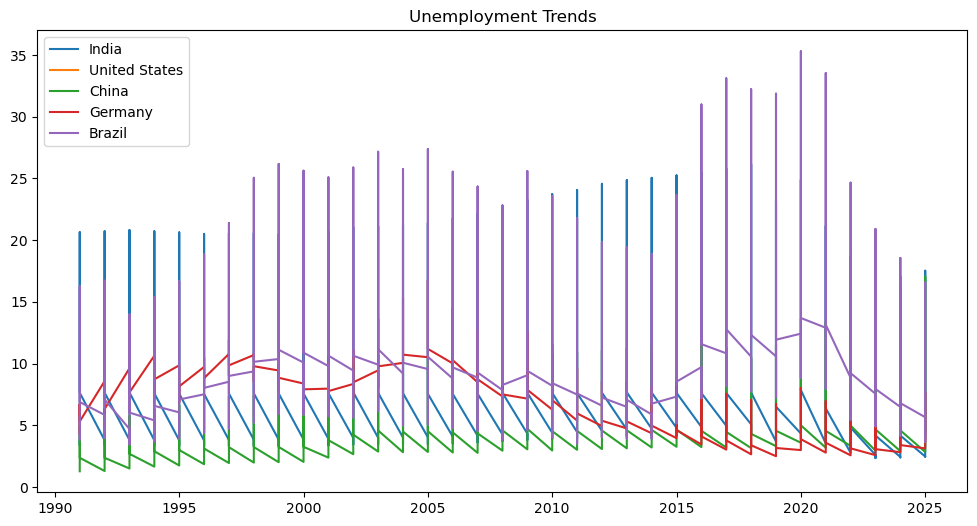

In [48]:
countries = ["India", "United States", "China", "Germany", "Brazil"]
plt.figure(figsize=(12,6))
for c in countries:
    data = df[df["country"] == c]
    plt.plot(data["year"], data["obs_value"], label=c)
plt.legend()
plt.title("Unemployment Trends")
plt.show()

# India job market shock visualization

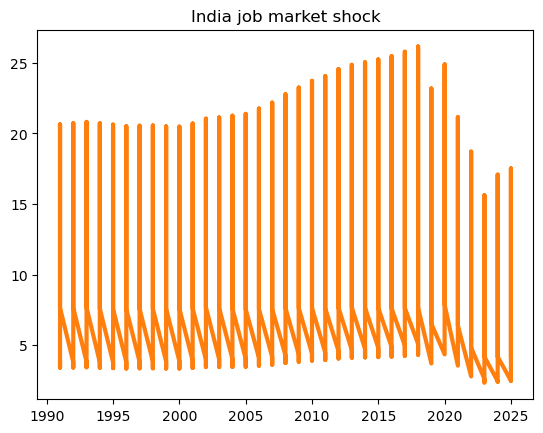

In [49]:
india = df[df["country"] == "India"]
plt.plot(india["year"], india["obs_value"])
plt.plot(india["year"], india["obs_value"], linewidth=3)
#lt.axvspan(2008, 2010, alpha=0.2)
#plt.axvspan(2020, 2021, alpha=0.2)
plt.title("India job market shock")
plt.show()

# Predict next 5 year unemployment  

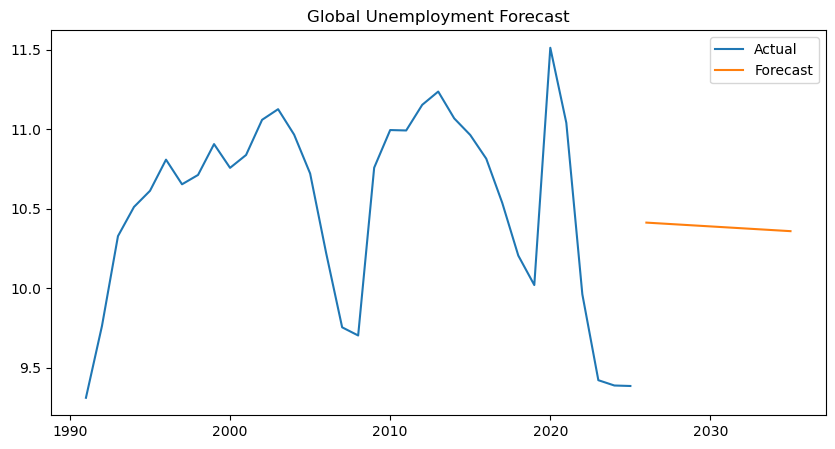

In [50]:
g = year.reset_index()
g["time"] = np.arange(len(g))
model = LinearRegression()
model.fit(g[["time"]], g["obs_value"])
future = pd.DataFrame({
    "time": np.arange(len(g), len(g)+10)
})
pred = model.predict(future)
future_years = np.arange(g["year"].iloc[-1]+1, g["year"].iloc[-1]+11)
plt.figure(figsize=(10,5))
plt.plot(g["year"], g["obs_value"], label="Actual")
plt.plot(future_years, pred, label="Forecast")
plt.legend()
plt.title("Global Unemployment Forecast")
plt.show()

# Covid-19 impact analysis

In [33]:
after_covid = df[df["year"] >= 2019]
before_covid = df[df["year"] < 2019]

print("After Covid:-", after_covid["obs_value"].mean())
print("Before Covid:-", before_covid["obs_value"].mean())

After Covid:- 10.112667017451548
Before Covid:- 10.625320344349033


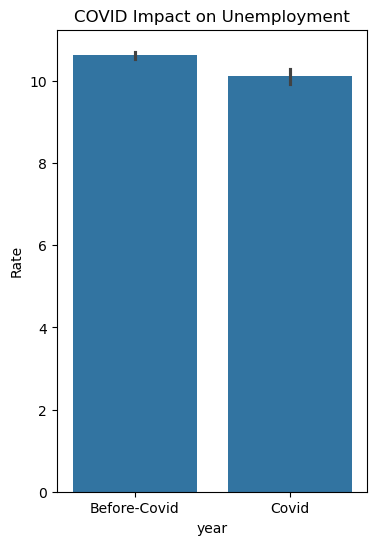

In [34]:
# covid impact
plt.figure(figsize=(4,6))
sns.barplot(x = df["year"] >= 2019, y = df["obs_value"])
plt.xticks([0,1], ['Before-Covid','Covid'])
plt.title("COVID Impact on Unemployment")
plt.xlabel("year")
plt.ylabel("Rate")
plt.show()



# Country wise analysis

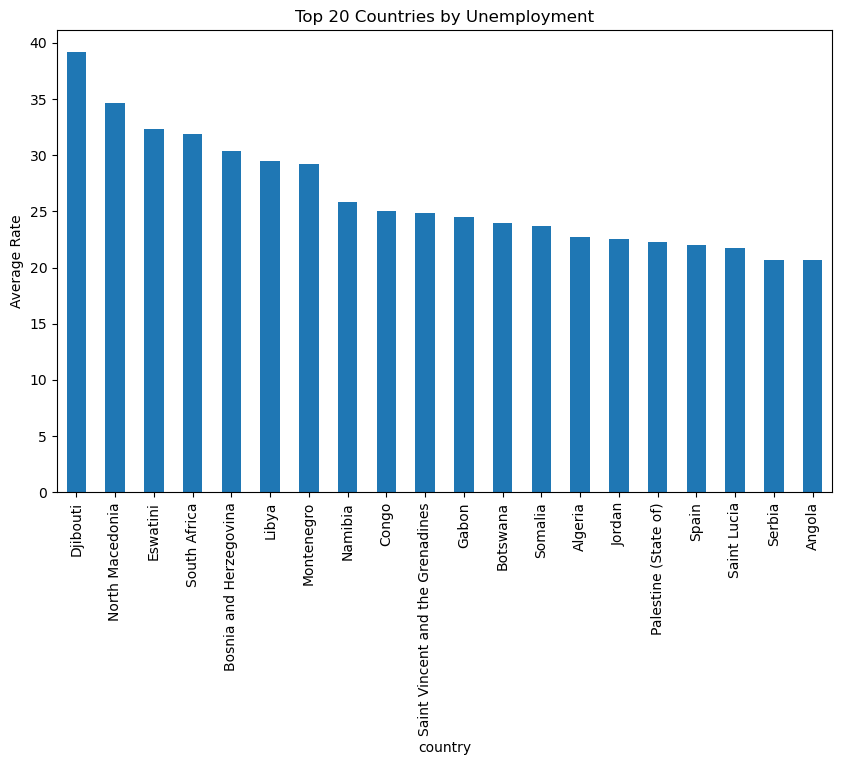

In [35]:
Country = df.groupby("country")["obs_value"].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
Country.plot(kind = "bar")
plt.title("Top 20 Countries by Unemployment")
plt.ylabel("Average Rate")
plt.show()

# Country by unemployment risk

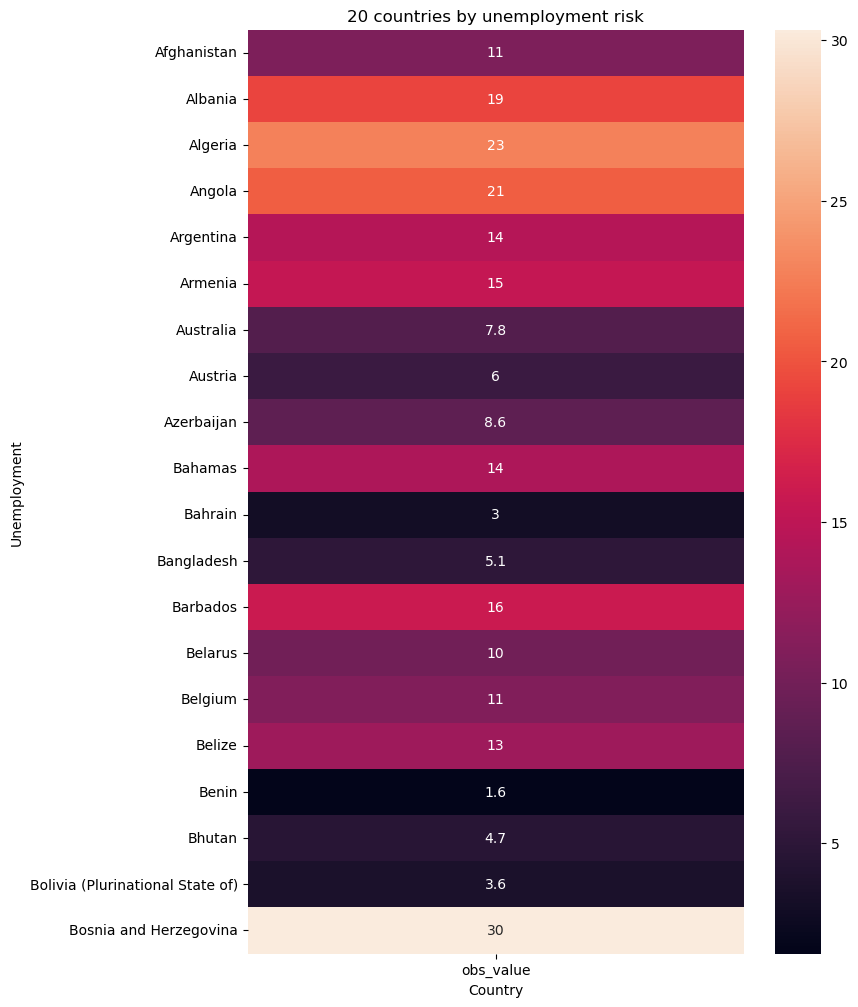

In [36]:
plt.figure(figsize=(8,12))
data = df.pivot_table(index="country",values="obs_value").head(20)
sns.heatmap(data,annot=True)
plt.title("20 countries by unemployment risk")
plt.xlabel("Country")
plt.ylabel("Unemployment")
plt.show()

# Key Insights

In [ ]:
1. Unemployment Increased During COVID-19
The dataset shows a sharp rise in unemployment rates during the COVID-19 period (2020). Lockdowns, business closures, and reduced economic activities 
caused job losses in many countries/states.

2. Some Countries/Regions Were More Affected
Not all countries had the same unemployment trend. Some regions experienced a much higher unemployment rate compared to others because of differences
in:
Economic structure
Government policies
Industrial dependency
Pandemic control measures
    
3. Recovery Started After Lockdowns
After the peak COVID period, unemployment rates gradually started decreasing due to:
Reopening of industries
Government support programs
Increase in business activities
Remote work opportunities
    
4. Year-wise Trend Shows Economic Impact
The line plots and yearly analysis clearly indicate that unemployment changes with major economic events. Sudden spikes usually represent economic 
crises or disruptions
    
5. Correlation Between Time and Unemployment
Time-series analysis helps identify:
Seasonal patterns
Economic cycles
Long-term unemployment trends
This can help governments predict future employment conditions
    
6. Data Visualization Helped Understand Patterns
Using graphs like:
Line plots
Heatmaps
Bar charts
made it easier to compare unemployment trends across countries and years

# Conclusion

In [ ]:
The unemployment analysis revealed that COVID-19 had a significant impact on global employment rates. Many countries experienced a sharp increase in 
unemployment during thepandemic period. However, gradual recovery was observed after restrictions were lifted and economic activities resumed.
    
Data analysis and visualization techniques in Python helped identify trends, compare country-wise performance, and understand the economic impact over
time. These insights can help policymakers and organizations create better employment strategies and economic recovery plans.
    
Overall, the project demonstrated how data science can be used to analyze real-world economic problems and support informed decision-making.